In [ ]:
from ggner_3d.cm import CLR_CONNS, get_expected_cis_df, prepare_view_df
from ggner_3d.boundaries import preserved_boundaries_only, make_tads, assign_domain_score
import pandas as pd

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

resolution = 10_000
window = 500_000
NPROC = 10

In [ ]:
clr_ = CLR_CONNS(resolution=resolution)
expected_dict = {
    k: get_expected_cis_df(k, resolution_kb=resolution // 1_000, label='chrom') for k in clr_.keys()
}


In [ ]:
def chrom_to_bin_indices(df, bins_table, bin_column = 'idx1'):
    df = df.copy()
    bins_table['indices'] = bins_table.index
    return pd.merge(df, bins_table, left_on=bin_column, right_on='indices')

insulation_tables = [
    pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_WTnoUV_10000bp.csv'),
    pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_WT3h_10000bp.csv'),
    pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_XPCnoUV_10000bp.csv'),
]

comparisons = [(0,1), (0,2)]
comparisons_str = ['WTnoUV_WT3h', 'WTnoUV_XPCnoUV']
sample_names_str = ['WTnoUV', 'WT3h', 'XPCnoUV']
accepted_range = 1

results, dfs = preserved_boundaries_only(
    comparisons=comparisons,
    comparisons_str=comparisons_str,
    sample_names_str=sample_names_str,
    accepted_range=accepted_range,
    insulation_table_=insulation_tables,
    window=window,
)

dfs = [
    chrom_to_bin_indices(df, clr_['WTnoUV'].bins()[:], bin_column='idx1') for df in dfs
]

In [ ]:
tads_wt_prepostuv = make_tads(dfs[0][['chrom', 'start', 'end']], maxlen=3e6).sort_values(['chrom', 'start', 'end']).reset_index(drop=True)
tads_wt_xpc = make_tads(dfs[1][['chrom', 'start', 'end']], maxlen=3e6).sort_values(['chrom', 'start', 'end']).reset_index(drop=True)

### wt nouv vs wt postuv prep

In [ ]:
wtnouv_df = assign_domain_score(tads_wt_prepostuv, 
                    clr=clr_['WTnoUV'],
                    expected=expected_dict['WTnoUV'],
                    view_df=prepare_view_df(arm=False),
                    resolution=resolution,
                    nproc=NPROC,
                    clr_weight_name='sweight',
                    ignore_diags=2
                    )

wt3h_df = assign_domain_score(tads_wt_prepostuv, 
                    clr=clr_['WT3h'],
                    expected=expected_dict['WT3h'],
                    view_df=prepare_view_df(arm=False),
                    resolution=resolution,
                    nproc=NPROC,
                    clr_weight_name='sweight',
                    ignore_diags=2
                    )

tads_wt_prepostuv = pd.merge(
    wtnouv_df[['chrom', 'start', 'end', 'domain_score']],
    wt3h_df[['chrom', 'start', 'end', 'domain_score']],
    on=['chrom', 'start', 'end'],
    suffixes=('_WTnoUV', '_WT3h')
)

tads_wt_prepostuv['ds_diff'] = tads_wt_prepostuv['domain_score_WT3h'] - tads_wt_prepostuv['domain_score_WTnoUV']
tads_wt_prepostuv['ds_diff_Q'] = pd.qcut(tads_wt_prepostuv['ds_diff'], q=4, labels=False) + 1

### wt nouv vs xpc nouv prep

In [ ]:
wtnouv_df = assign_domain_score(tads_wt_xpc, 
                    clr=clr_['WTnoUV'],
                    expected=expected_dict['WTnoUV'],
                    view_df=prepare_view_df(arm=False),
                    resolution=resolution,
                    nproc=NPROC,
                    clr_weight_name='sweight',
                    ignore_diags=2
                    )

xpc_df = assign_domain_score(tads_wt_xpc, 
                    clr=clr_['XPCnoUV'],
                    expected=expected_dict['XPCnoUV'],
                    view_df=prepare_view_df(arm=False),
                    resolution=resolution,
                    nproc=NPROC,
                    clr_weight_name='sweight',
                    ignore_diags=2
                    )

tads_wt_xpc = pd.merge(
    wtnouv_df[['chrom', 'start', 'end', 'domain_score']],
    xpc_df[['chrom', 'start', 'end', 'domain_score']],
    on=['chrom', 'start', 'end'],
    suffixes=('_WTnoUV', '_XPCnoUV')
)

tads_wt_xpc['ds_diff'] = tads_wt_xpc['domain_score_XPCnoUV'] - tads_wt_xpc['domain_score_WTnoUV']
tads_wt_xpc['ds_diff_Q'] = pd.qcut(tads_wt_xpc['ds_diff'], q=4, labels=False) + 1

### saddle

In [215]:
import importlib
from ggner_3d import saddle_mp
importlib.reload(saddle_mp)
import numpy as np

median_tad_size = (tads_wt_prepostuv['end'] - tads_wt_prepostuv['start']).median()

min_range = 1e7
max_range = np.inf

weight_mode = 'pair'

In [216]:
out_wtnouv = saddle_mp.saddle_by_interval_category_cis(
    clr=clr_["WTnoUV"],
    expected_df=expected_dict["WTnoUV"],
    intervals_df=tads_wt_prepostuv,
    category_col="ds_diff_Q",
    categories=[1, 2, 3, 4],
    midpoint_dist_range=(min_range, max_range),
    expected_value_col="balanced.avg",
    balance="sweight",
    weight_mode=weight_mode,
    ignore_diags=2,
    use_tqdm=True,
)

out_wtpostuv = saddle_mp.saddle_by_interval_category_cis(
    clr=clr_["WT3h"],
    expected_df=expected_dict["WT3h"],
    intervals_df=tads_wt_prepostuv,
    category_col="ds_diff_Q",
    categories=[1, 2, 3, 4],
    midpoint_dist_range=(min_range, max_range),
    expected_value_col="balanced.avg",
    balance="sweight",
    weight_mode=weight_mode,
    ignore_diags=2,
    use_tqdm=True,
)

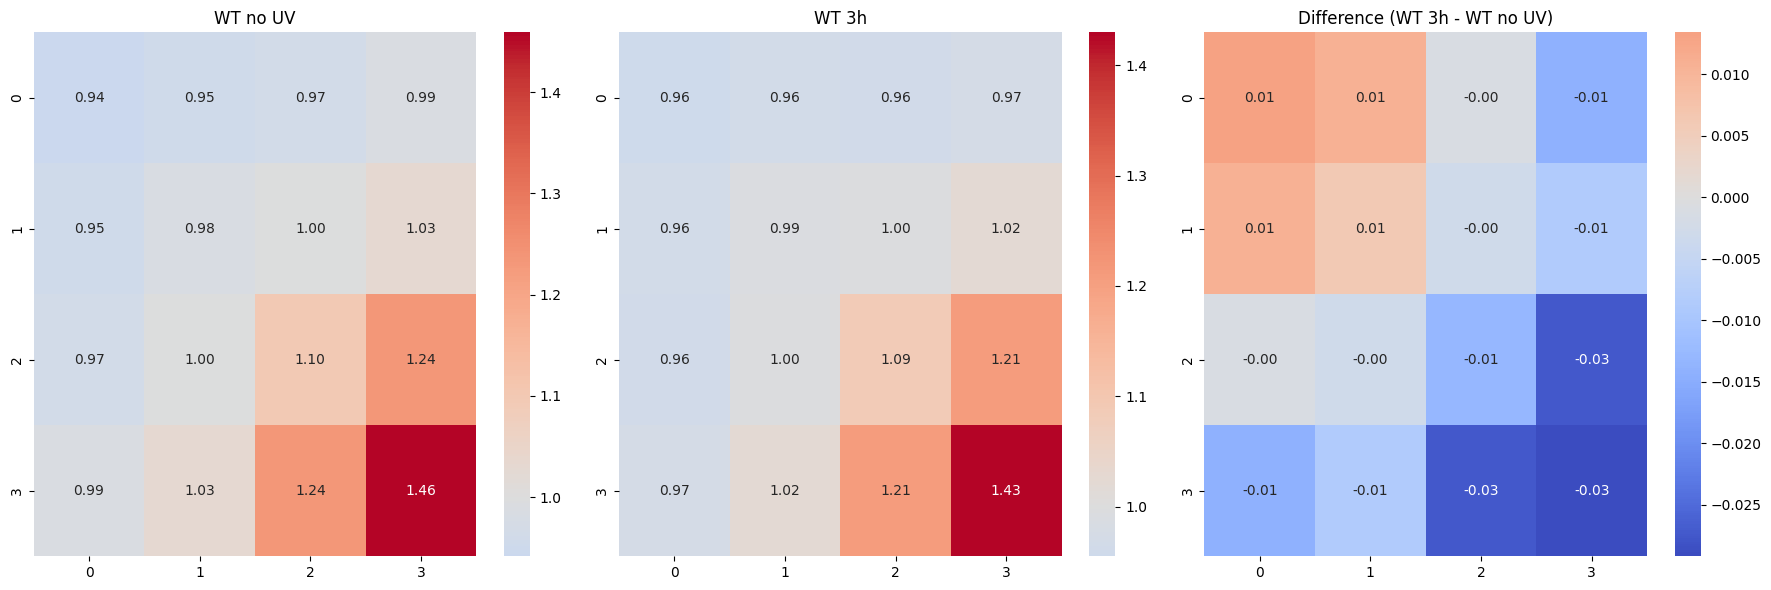

In [217]:
import seaborn as sns
import matplotlib.pyplot as plt

wt_nouv_saddle_oe = pd.DataFrame(out_wtnouv["oe"], index=out_wtnouv["categories"], columns=out_wtnouv["categories"])
wt_postuv_saddle_oe = pd.DataFrame(out_wtpostuv["oe"], index=out_wtpostuv["categories"], columns=out_wtpostuv["categories"])

wt_nouv_saddle_oe = np.array(wt_nouv_saddle_oe)
wt_postuv_saddle_oe = np.array(wt_postuv_saddle_oe)
diff = wt_postuv_saddle_oe - wt_nouv_saddle_oe
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
sns.heatmap(wt_nouv_saddle_oe, annot=True, fmt=".2f", ax=ax[0], cmap="coolwarm", center=1)
ax[0].set_title("WT no UV")
sns.heatmap(wt_postuv_saddle_oe, annot=True, fmt=".2f", ax=ax[1], cmap="coolwarm", center=1)
ax[1].set_title("WT 3h")
sns.heatmap(diff, annot=True, fmt=".2f", ax=ax[2], cmap="coolwarm", center=0)
ax[2].set_title("Difference (WT 3h - WT no UV)")
plt.tight_layout()

In [218]:
out_wtnouv = saddle_mp.saddle_by_interval_category_cis(
    clr=clr_["WTnoUV"],
    expected_df=expected_dict["WTnoUV"],
    intervals_df=tads_wt_xpc,
    category_col="ds_diff_Q",
    categories=[1, 2, 3, 4],
    midpoint_dist_range=(min_range, max_range),
    expected_value_col="balanced.avg",
    balance="sweight",
    weight_mode=weight_mode,
    ignore_diags=2,
    use_tqdm=True,
)

out_xpc = saddle_mp.saddle_by_interval_category_cis(
    clr=clr_["XPCnoUV"],
    expected_df=expected_dict["XPCnoUV"],
    intervals_df=tads_wt_xpc,
    category_col="ds_diff_Q",
    categories=[1, 2, 3, 4],
    midpoint_dist_range=(min_range, max_range),
    expected_value_col="balanced.avg",
    balance="sweight",
    weight_mode=weight_mode,
    ignore_diags=2,
    use_tqdm=True,
)

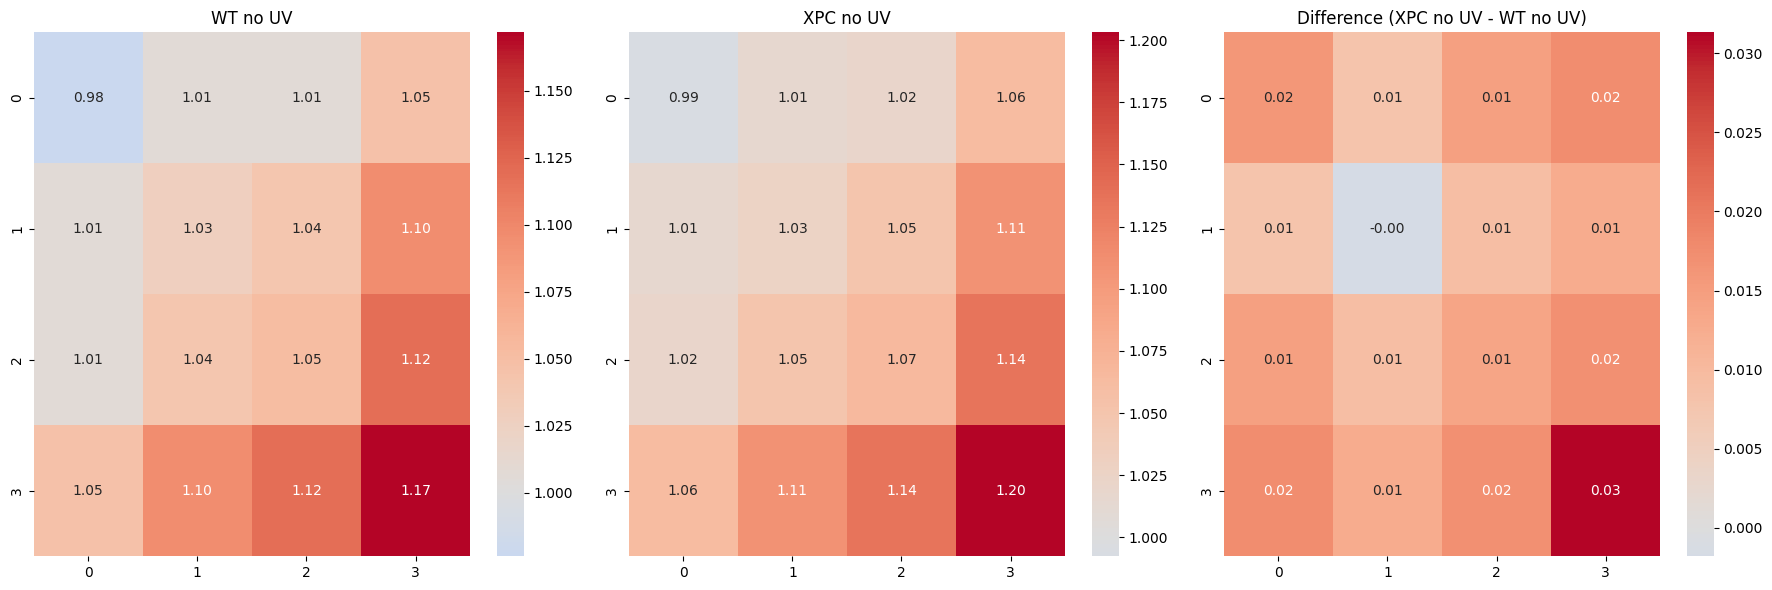

In [219]:
import seaborn as sns
import matplotlib.pyplot as plt

wt_nouv_saddle_oe = pd.DataFrame(out_wtnouv["oe"], index=out_wtnouv["categories"], columns=out_wtnouv["categories"])
wt_xpc_saddle_oe = pd.DataFrame(out_xpc["oe"], index=out_xpc["categories"], columns=out_xpc["categories"])

wt_nouv_saddle_oe = np.array(wt_nouv_saddle_oe)
wt_xpc_saddle_oe = np.array(wt_xpc_saddle_oe)
diff = wt_xpc_saddle_oe - wt_nouv_saddle_oe
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
sns.heatmap(wt_nouv_saddle_oe, annot=True, fmt=".2f", ax=ax[0], cmap="coolwarm", center=1)
ax[0].set_title("WT no UV")
sns.heatmap(wt_xpc_saddle_oe, annot=True, fmt=".2f", ax=ax[1], cmap="coolwarm", center=1)
ax[1].set_title("XPC no UV")
sns.heatmap(diff, annot=True, fmt=".2f", ax=ax[2], cmap="coolwarm", center=0)
ax[2].set_title("Difference (XPC no UV - WT no UV)")
plt.tight_layout()

In [220]:
out_wtnouv = saddle_mp.saddle_by_interval_category_cis(
    clr=clr_["WTnoUV"],
    expected_df=expected_dict["WTnoUV"],
    intervals_df=tads_wt_prepostuv,
    category_col="ds_diff_Q",
    categories=[1, 2, 3, 4],
    midpoint_dist_range=(min_range, max_range),
    expected_value_col="balanced.avg",
    balance="sweight",
    weight_mode=weight_mode,
    ignore_diags=2,
    use_tqdm=True,
)

out_xpc = saddle_mp.saddle_by_interval_category_cis(
    clr=clr_["XPCnoUV"],
    expected_df=expected_dict["XPCnoUV"],
    intervals_df=tads_wt_prepostuv,
    category_col="ds_diff_Q",
    categories=[1, 2, 3, 4],
    midpoint_dist_range=(min_range, max_range),
    expected_value_col="balanced.avg",
    balance="sweight",
    weight_mode=weight_mode,
    ignore_diags=2,
    use_tqdm=True,
)

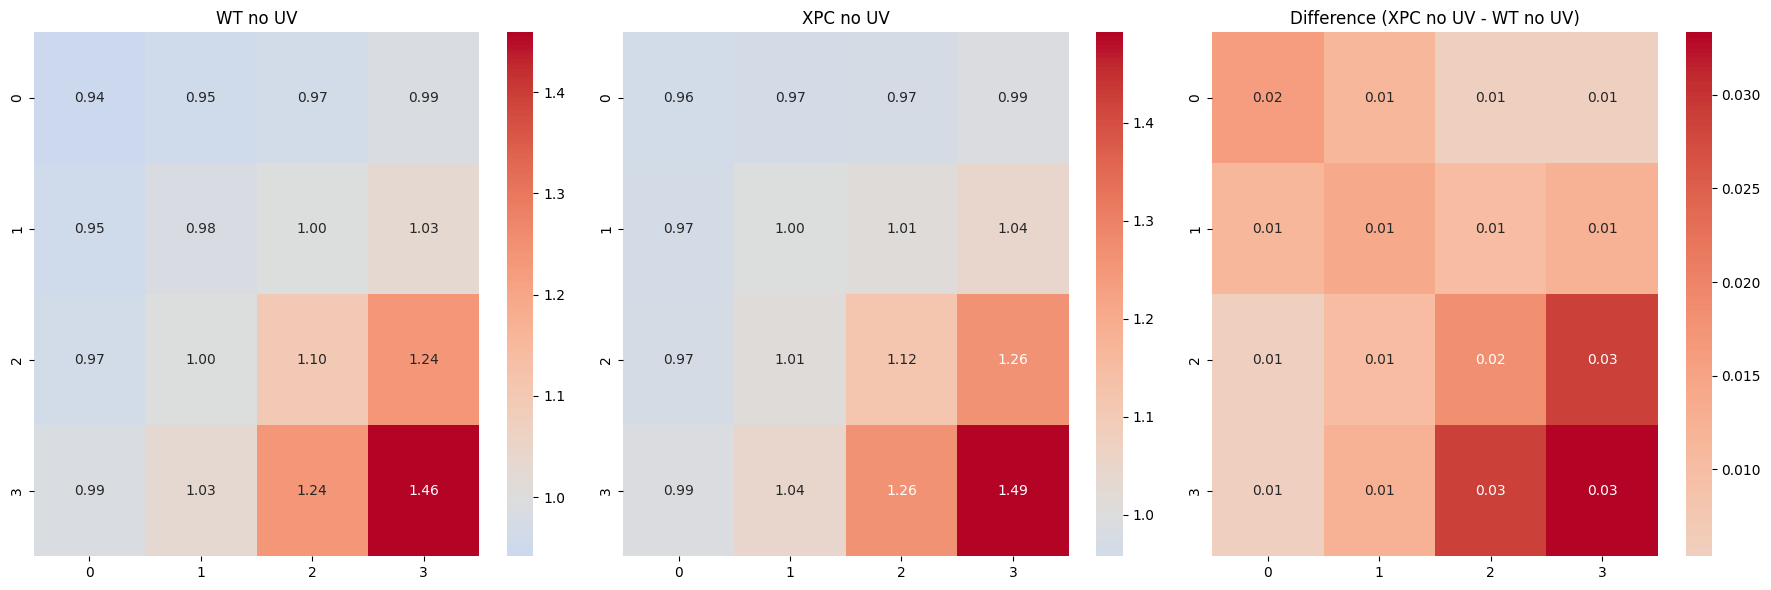

In [221]:
import seaborn as sns
import matplotlib.pyplot as plt

wt_nouv_saddle_oe = pd.DataFrame(out_wtnouv["oe"], index=out_wtnouv["categories"], columns=out_wtnouv["categories"])
wt_xpc_saddle_oe = pd.DataFrame(out_xpc["oe"], index=out_xpc["categories"], columns=out_xpc["categories"])

wt_nouv_saddle_oe = np.array(wt_nouv_saddle_oe)
wt_xpc_saddle_oe = np.array(wt_xpc_saddle_oe)
diff = wt_xpc_saddle_oe - wt_nouv_saddle_oe
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
sns.heatmap(wt_nouv_saddle_oe, annot=True, fmt=".2f", ax=ax[0], cmap="coolwarm", center=1)
ax[0].set_title("WT no UV")
sns.heatmap(wt_xpc_saddle_oe, annot=True, fmt=".2f", ax=ax[1], cmap="coolwarm", center=1)
ax[1].set_title("XPC no UV")
sns.heatmap(diff, annot=True, fmt=".2f", ax=ax[2], cmap="coolwarm", center=0)
ax[2].set_title("Difference (XPC no UV - WT no UV)")
plt.tight_layout()

In [ ]:
from ggner_3d.cm import scaled_balanced_cool_dump_streaming
dump_folder = '/home/carlos/Clone/ggner-3d/data/scaled_cools_full'
resolution_for_scaling=100_000

clr_scaling = CLR_CONNS(resolution_for_scaling)

for sample_name, clr in zip(['WTnoUV', 'WT3h', 'XPCnoUV'], [clr_scaling['WTnoUV'], clr_scaling['WT3h'], clr_scaling['XPCnoUV']]):
    scaled_balanced_cool_dump_streaming(
        clr=clr,
        dump_path = f"{dump_folder}/{sample_name}_scaled_balanced_{resolution_for_scaling}.cool",
        cis_only=False,
        weight_name='sweight',
    )

In [200]:
import cooler

from ggner_3d import boundaries
importlib.reload(boundaries)
from ggner_3d.boundaries import genomewide_full_tad2tad_from_pixel_field, genomewide_full_tad2tad_from_pixel_field_full

scaled_clr = {
    'WTnoUV': cooler.Cooler('/home/carlos/Clone/ggner-3d/data/scaled_cools_full/WTnoUV_scaled_balanced_100000.cool'),
    'WT3h': cooler.Cooler('/home/carlos/Clone/ggner-3d/data/scaled_cools_full/WT3h_scaled_balanced_100000.cool'),
    'XPCnoUV': cooler.Cooler('/home/carlos/Clone/ggner-3d/data/scaled_cools_full/XPCnoUV_scaled_balanced_100000.cool'),
}

In [205]:


wtnouv_mtx_1, wtnouv_meta, wtnouv_per = genomewide_full_tad2tad_from_pixel_field_full(
    scaled_clr['WTnoUV'],
    tads_wt_prepostuv,
    field="scaled",
    agg='mean',
    ignore_diagonal=2,
    )

wt3h_mtx, wt3h_meta, wt3h_per = genomewide_full_tad2tad_from_pixel_field_full(
    scaled_clr['WT3h'],
    tads_wt_prepostuv,
    field="scaled",
    agg='mean',
    ignore_diagonal=2,
    )

wtnouv_mtx_2, wtnouv_meta, wtnouv_per = genomewide_full_tad2tad_from_pixel_field_full(
    scaled_clr['WTnoUV'],
    tads_wt_xpc,
    field="scaled",
    agg='mean',
    ignore_diagonal=2,
    )

xpc_mtx, xpc_meta, xpc_per = genomewide_full_tad2tad_from_pixel_field_full(
    scaled_clr['XPCnoUV'],
    tads_wt_xpc,
    field="scaled",
    agg='mean',
    ignore_diagonal=2,
    )

In [206]:
import numpy as np
import pandas as pd

def aggregate_matrix_by_quartiles(M, quartiles, agg="mean"):

    q = np.asarray(quartiles)
    result = np.full((4,4), np.nan)

    for i in range(1,5):
        rmask = q == i

        for j in range(1,5):
            cmask = q == j

            block = M[np.ix_(rmask, cmask)]

            if block.size == 0:
                continue

            if agg == "mean":
                result[i-1, j-1] = np.nanmean(block)

            elif agg == "sum":
                result[i-1, j-1] = np.nansum(block)

            else:
                raise ValueError("agg must be 'mean' or 'sum'")

    return result

def aggregate_matrix_by_quartiles_nan_df(M, quartiles, agg="mean"):
    res = aggregate_matrix_by_quartiles(M, quartiles, agg)
    return pd.DataFrame(res, index=[1,2,3,4], columns=[1,2,3,4])

wtnouv1_mtx_agg = aggregate_matrix_by_quartiles_nan_df(wtnouv_mtx_1, tads_wt_prepostuv['ds_diff_Q'], agg='mean')
wt3h_mtx_agg = aggregate_matrix_by_quartiles_nan_df(wt3h_mtx, tads_wt_prepostuv['ds_diff_Q'], agg='mean')
wtnouv2_mtx_agg = aggregate_matrix_by_quartiles_nan_df(wtnouv_mtx_2, tads_wt_xpc['ds_diff_Q'], agg='mean')
xpc_mtx_agg = aggregate_matrix_by_quartiles_nan_df(xpc_mtx, tads_wt_xpc['ds_diff_Q'], agg='mean')

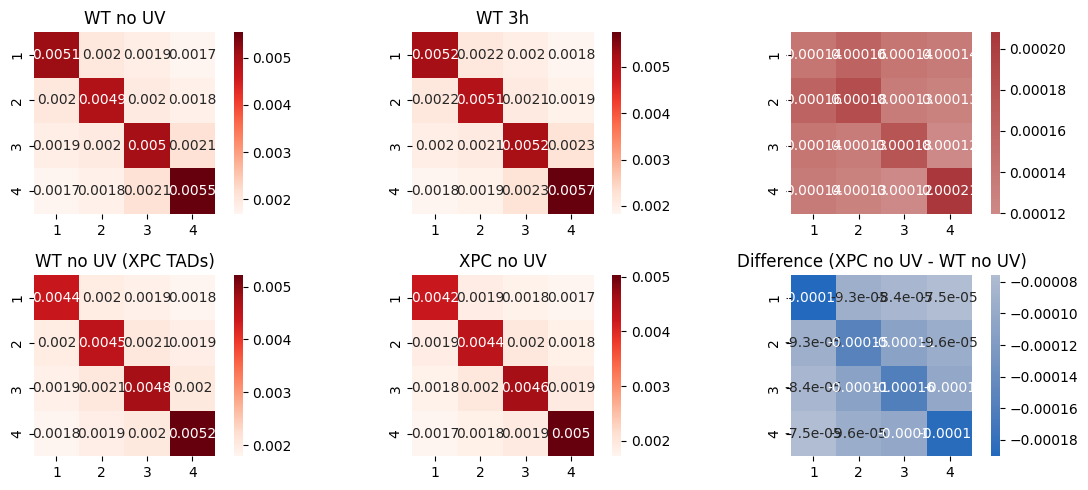

In [207]:
fig, axs = plt.subplots(2, 3, figsize=(12, 5))
sns.heatmap(wtnouv1_mtx_agg, annot=True,  ax=axs[0,0], cmap="Reds", square=True)
axs[0,0].set_title("WT no UV")
sns.heatmap(wt3h_mtx_agg, annot=True,  ax=axs[0,1], cmap="Reds", square=True)
axs[0,1].set_title("WT 3h")
diff_agg = wt3h_mtx_agg - wtnouv1_mtx_agg
sns.heatmap(diff_agg, annot=True, ax=axs[0,2], cmap="vlag", square=True, center=0)

sns.heatmap(wtnouv2_mtx_agg, annot=True,  ax=axs[1,0], cmap="Reds", square=True)
axs[1,0].set_title("WT no UV (XPC TADs)")
sns.heatmap(xpc_mtx_agg, annot=True,  ax=axs[1,1], cmap="Reds", square=True)
axs[1,1].set_title("XPC no UV")
diff_agg_2 = xpc_mtx_agg - wtnouv2_mtx_agg
sns.heatmap(diff_agg_2, annot=True, ax=axs[1,2], cmap="vlag", square=True, center=0)
axs[1,2].set_title("Difference (XPC no UV - WT no UV)")
plt.tight_layout()